# Fase 3.4: Triangulación Definitiva — Cruce Survey × Stack Overflow

Este cuaderno ejecuta la **fase de triangulación** del framework I2A: cruzamos la señal de la comunidad técnica (volumen y tendencia de preguntas en Stack Overflow) con la señal del mercado laboral (encuesta de desarrolladores — _used_ vs _wanted_).

**Pregunta central:** _¿Están correlacionadas las preguntas de la comunidad con lo que el mercado laboral desea?_

**Inputs:**
| Artefacto | Ruta |
|---|---|
| Survey Unificado (2017-2024) | `../data/datos_procesados/survey_unificado.parquet` |
| Clasificación SO (Top 20) | `../data/datos_procesados/eda/clasificacion.parquet` |

**Output:** `../data/datos_procesados/eda/tabla_cruce_final.parquet`

In [7]:
import polars as pl
import plotly.express as px
import plotly.graph_objects as go
import sys, os
import plotly.io as pio
pio.renderers.default = "png"

# Importar funciones modulares desde src
sys.path.append(os.path.abspath('..'))
from src.survey_utils import calcular_demand_gap, pearson_correlation, normalizar_tag_survey

# ── Rutas ──
SURVEY_PATH   = '../data/datos_procesados/survey_unificado.parquet'
CLASIF_PATH   = '../data/datos_procesados/eda/clasificacion.parquet'
OUTPUT_PATH   = '../data/datos_procesados/eda/tabla_cruce_final.parquet'

print('✅ Librerías y módulos cargados correctamente.')

✅ Librerías y módulos cargados correctamente.


---
## 1. Ingesta y Cálculo de la Brecha de Demanda (_Demand Gap_)

La **Brecha de Demanda** se define como:

$$\text{Demand\_Gap} = \text{wanted\_pct} - \text{used\_pct}$$

- **Brecha positiva** → Más gente _quiere_ aprender la tecnología que la que ya la _usa_. Señal de **alta tracción laboral**.
- **Brecha negativa** → Más gente la usa que la que quiere aprenderla. Posible señal de **saturación o declive**.

Filtramos exclusivamente al año **2024** (último disponible) para obtener la foto más actual del mercado.

In [8]:
# 1.1 Carga lazy del survey unificado
survey_lf = pl.scan_parquet(SURVEY_PATH)

# 1.2 Detectar el último año disponible y filtrar
ultimo_ano = survey_lf.select(pl.col('year').max()).collect().item()
print(f'📅 Último año disponible en el survey: {ultimo_ano}')

# 1.3 Pipeline lazy: filtrar → normalizar tag → calcular demand gap
survey_2024 = (
    survey_lf
    .filter(pl.col('year') == ultimo_ano)
    .with_columns(normalizar_tag_survey('tag'))
    .pipe(calcular_demand_gap)
    .collect()
)

print(f'\n📊 Tecnologías en el survey {ultimo_ano}: {survey_2024.shape[0]}')
print(f'\n🔝 Top 10 con MAYOR Brecha de Demanda (alta tracción):')
display(survey_2024.sort('Demand_Gap', descending=True).head(10))

print(f'\n🔻 Top 5 con MENOR Brecha de Demanda (saturación):')
display(survey_2024.sort('Demand_Gap').head(5))

📅 Último año disponible en el survey: 2024

📊 Tecnologías en el survey 2024: 50

🔝 Top 10 con MAYOR Brecha de Demanda (alta tracción):


year,tag,used_pct,wanted_pct,n_respondents,Demand_Gap
i32,str,f64,f64,u32,f64
2024,"""rust""",0.115516,0.263337,65437,0.147822
2024,"""go""",0.123829,0.211455,65437,0.087626
2024,"""na""",0.086984,0.148005,65437,0.061021
2024,"""zig""",0.010193,0.05636,65437,0.046167
2024,"""kotlin""",0.086572,0.112765,65437,0.026193
2024,"""elixir""",0.018995,0.044241,65437,0.025246
2024,"""swift""",0.043232,0.059248,65437,0.016015
2024,"""haskell""",0.018231,0.033941,65437,0.01571
2024,"""f#""",0.007824,0.019439,65437,0.011614



🔻 Top 5 con MENOR Brecha de Demanda (saturación):


year,tag,used_pct,wanted_pct,n_respondents,Demand_Gap
i32,str,f64,f64,u32,f64
2024,"""javascript""",0.572948,0.363311,65437,-0.209637
2024,"""html""",0.486208,0.316656,65437,-0.169552
2024,"""sql""",0.468878,0.342314,65437,-0.126564
2024,"""java""",0.278726,0.163027,65437,-0.115699
2024,"""bash""",0.311934,0.210034,65437,-0.1019


---
### 1.5 Visualización del Mercado Laboral (Survey)

Antes de cruzar con Stack Overflow, exploramos visualmente el panorama del survey 2024 mediante dos gráficas:

1. **Gráfico de Barras (Brecha de Demanda):** Muestra el `Demand_Gap` de TODAS las tecnologías en 2024, ordenado de mayor a menor, con color dependiente del signo de la brecha.
2. **Scatter Clásico (Used vs Wanted):** Enfrenta el porcentaje de uso (`used_pct`) contra el porcentaje de deseo (`wanted_pct`), con una línea diagonal de referencia que marca el punto de equilibrio donde `Used = Wanted`.

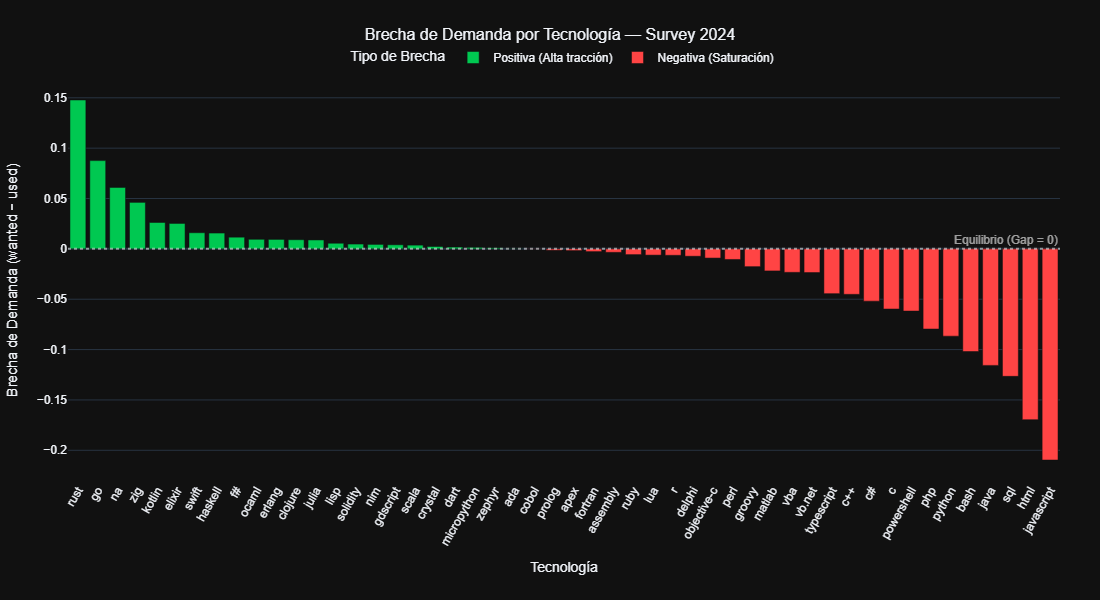

📊 Total de tecnologías visualizadas: 50


In [10]:
# ── 1.5.1  Gráfico de Barras — Brecha de Demanda (todas las tecnologías 2024) ──

# Ordenar de mayor a menor Demand_Gap
df_gap = survey_2024.sort('Demand_Gap', descending=True)

# Crear columna de color según el signo de la brecha
df_gap = df_gap.with_columns(
    pl.when(pl.col('Demand_Gap') >= 0)
      .then(pl.lit('Positiva (Alta tracción)'))
      .otherwise(pl.lit('Negativa (Saturación)'))
      .alias('Tipo_Brecha')
)

# Convertir a pandas para Plotly Express
df_gap_pd = df_gap.to_pandas()

fig_bar = px.bar(
    df_gap_pd,
    x='tag',
    y='Demand_Gap',
    color='Tipo_Brecha',
    color_discrete_map={
        'Positiva (Alta tracción)': '#00C851',   # Verde vibrante
        'Negativa (Saturación)':    '#FF4444',   # Rojo
    },
    labels={
        'tag': 'Tecnología',
        'Demand_Gap': 'Brecha de Demanda (wanted − used)',
        'Tipo_Brecha': 'Tipo de Brecha',
    },
    title='Brecha de Demanda por Tecnología — Survey 2024',
    hover_data={'used_pct': ':.2%', 'wanted_pct': ':.2%', 'Demand_Gap': ':.4f'},
)

fig_bar.update_layout(
    template='plotly_dark',
    height=600,
    width=1100,
    font=dict(family='Inter, sans-serif'),
    title_font_size=16,
    title_x=0.5,
    xaxis_tickangle=-60,
    legend=dict(
        orientation='h',
        yanchor='bottom', y=1.02,
        xanchor='center', x=0.5,
    ),
    margin=dict(l=60, r=40, t=80, b=120),
)

# Línea de referencia en y=0
fig_bar.add_hline(
    y=0, line_dash='dot', line_color='rgba(255,255,255,0.5)',
    annotation_text='Equilibrio (Gap = 0)',
    annotation_position='top right',
    annotation_font_color='rgba(255,255,255,0.6)',
)

fig_bar.show()
print(f'📊 Total de tecnologías visualizadas: {df_gap.shape[0]}')

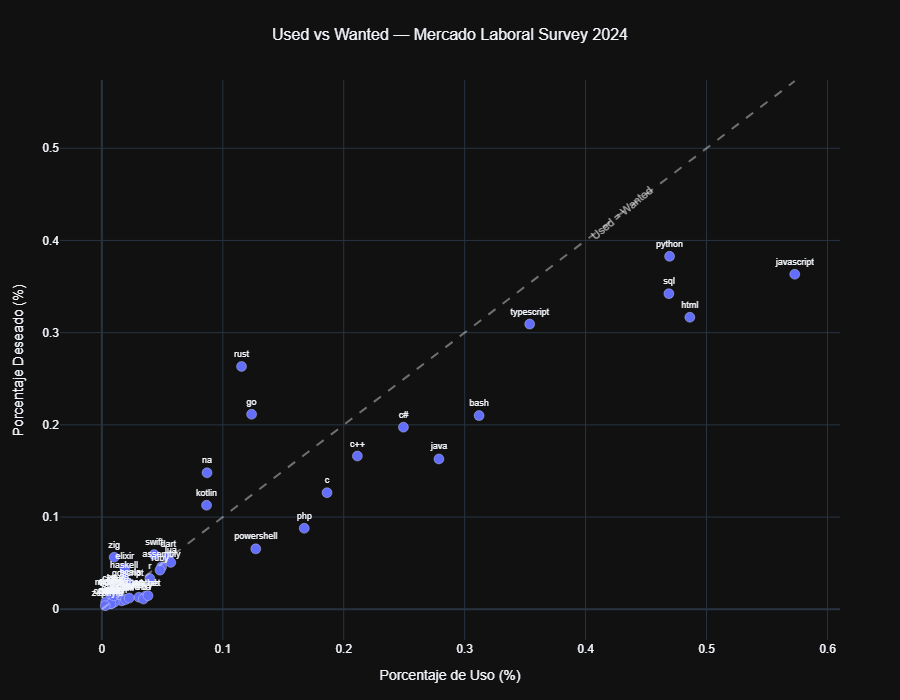

✅ Scatter con línea de equilibrio generado correctamente.


In [11]:
# ── 1.5.2  Scatter Clásico — Used vs Wanted con línea de equilibrio ──

df_scatter_pd = survey_2024.to_pandas()

fig_scatter = px.scatter(
    df_scatter_pd,
    x='used_pct',
    y='wanted_pct',
    text='tag',
    hover_data={
        'used_pct': ':.2%',
        'wanted_pct': ':.2%',
        'Demand_Gap': ':.4f',
    },
    labels={
        'used_pct': 'Porcentaje de Uso (%)',
        'wanted_pct': 'Porcentaje Deseado (%)',
    },
    title='Used vs Wanted — Mercado Laboral Survey 2024',
)

# ── Línea diagonal de referencia (Used = Wanted) ──
max_val = max(df_scatter_pd['used_pct'].max(), df_scatter_pd['wanted_pct'].max())

fig_scatter.add_shape(
    type='line',
    x0=0, y0=0,
    x1=max_val, y1=max_val,
    line=dict(color='rgba(255,255,255,0.4)', width=2, dash='dash'),
)

# Anotación descriptiva sobre la diagonal
fig_scatter.add_annotation(
    x=max_val * 0.75, y=max_val * 0.75,
    text='Used = Wanted',
    showarrow=False,
    font=dict(size=11, color='rgba(255,255,255,0.6)'),
    textangle=-40,
)

fig_scatter.update_traces(
    textposition='top center',
    textfont_size=9,
    marker=dict(size=10, line=dict(width=1, color='rgba(255,255,255,0.3)')),
)

fig_scatter.update_layout(
    template='plotly_dark',
    height=700,
    width=900,
    font=dict(family='Inter, sans-serif'),
    title_font_size=16,
    title_x=0.5,
    margin=dict(l=60, r=60, t=80, b=60),
)

fig_scatter.show()
print('✅ Scatter con línea de equilibrio generado correctamente.')

---
## 2. El Gran Cruce: Triangulación Survey × Stack Overflow

Realizamos un `inner join` entre:
- El **survey 2024** (con la Brecha de Demanda calculada).
- La **clasificación de Stack Overflow** (con la pendiente $\beta_1$, crecimiento %, $R^2$ y la categoría de tendencia).

La columna de join es `tag` (survey) ↔ `Tag` (clasificación). Se normalizan ambos a minúsculas para maximizar el cruce.

In [3]:
# 2.1 Cargar la clasificación de Stack Overflow
clasificacion = pl.read_parquet(CLASIF_PATH)
print(f'📋 Tecnologías en clasificación SO: {clasificacion.shape[0]}')
print(f'   Columnas: {clasificacion.columns}')

# 2.2 Normalizar la columna Tag de la clasificación a minúsculas
clasificacion = clasificacion.with_columns(
    pl.col('Tag').str.to_lowercase().alias('tag_join')
)

# 2.3 Preparar la columna de join del survey
survey_2024 = survey_2024.with_columns(
    pl.col('tag').str.to_lowercase().alias('tag_join')
)

# 2.4 INNER JOIN — solo las tecnologías presentes en AMBAS fuentes
df_cruce = survey_2024.join(
    clasificacion,
    on='tag_join',
    how='inner'
)

print(f'\n🔗 Tecnologías cruzadas exitosamente: {df_cruce.shape[0]}')
print(f'   Tags: {sorted(df_cruce["Tag"].to_list())}')

# 2.5 Mostrar el resultado del cruce
display(
    df_cruce.select([
        'Tag', 'used_pct', 'wanted_pct', 'Demand_Gap', 'n_respondents',
        'Crecimiento_Pct', 'Pendiente', 'R2', 'ViewCount_Promedio', 'Categoria_Tendencia'
    ]).sort('Demand_Gap', descending=True)
)

📋 Tecnologías en clasificación SO: 20
   Columnas: ['Tag', 'Volumen_Total', 'Share_2022', 'Share_2023', 'Crecimiento_Pct', 'Pendiente', 'R2', 'ViewCount_Promedio', 'Categoria_Tendencia']

🔗 Tecnologías cruzadas exitosamente: 10
   Tags: ['c#', 'c++', 'html', 'java', 'javascript', 'php', 'python', 'r', 'sql', 'swift']


Tag,used_pct,wanted_pct,Demand_Gap,n_respondents,Crecimiento_Pct,Pendiente,R2,ViewCount_Promedio,Categoria_Tendencia
str,f64,f64,f64,u32,f64,f64,f64,f64,str
"""swift""",0.043232,0.059248,0.016015,65437,9.59477,-37.579914,0.891148,1656.748629,"""Madurando"""
"""r""",0.039656,0.033269,-0.006388,65437,7.815021,-6.023008,0.053892,1076.103058,"""Madurando"""
"""c++""",0.211302,0.16616,-0.045143,65437,-5.00157,-42.383556,0.813809,1121.632289,"""Madurando"""
"""c#""",0.24937,0.197457,-0.051913,65437,14.389589,-98.754142,0.957667,1448.166374,"""Madurando"""
"""php""",0.167352,0.087794,-0.079557,65437,-3.54979,-135.502694,0.95818,1318.458252,"""Madurando"""
"""python""",0.469444,0.382765,-0.086679,65437,-5.8588,26.091804,0.03382,1957.520229,"""Madurando"""
"""java""",0.278726,0.163027,-0.115699,65437,10.154251,-145.406309,0.958553,1733.867257,"""Madurando"""
"""sql""",0.468878,0.342314,-0.126564,65437,-12.926598,-27.618656,0.686366,1079.134235,"""En Declive"""
"""html""",0.486208,0.316656,-0.169552,65437,-3.378943,-83.743138,0.921062,1414.636803,"""Madurando"""


---
## 3. Validación Estadística: Correlación de Pearson

Evaluamos si existe una relación lineal entre la **tendencia de Stack Overflow** (pendiente $\beta_1$ de la regresión temporal) y la **Brecha de Demanda** del survey.

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \cdot \sum (y_i - \bar{y})^2}}$$

| Rango de $|r|$ | Interpretación |
|---|---|
| 0.00 — 0.19 | Muy débil |
| 0.20 — 0.39 | Débil |
| 0.40 — 0.59 | Moderada |
| 0.60 — 0.79 | Fuerte |
| 0.80 — 1.00 | Muy fuerte |

In [4]:
# 3.1 Correlación: Pendiente (β₁) vs Demand Gap
r_pendiente = pearson_correlation(df_cruce, 'Pendiente', 'Demand_Gap')

# 3.2 Correlación complementaria: Crecimiento % vs Demand Gap
r_crecimiento = pearson_correlation(df_cruce, 'Crecimiento_Pct', 'Demand_Gap')

# 3.3 Interpretación automática
def interpretar_r(r: float) -> str:
    """Genera una interpretación ejecutiva del coeficiente de correlación."""
    abs_r = abs(r)
    if abs_r >= 0.80:
        fuerza = 'MUY FUERTE'
    elif abs_r >= 0.60:
        fuerza = 'FUERTE'
    elif abs_r >= 0.40:
        fuerza = 'MODERADA'
    elif abs_r >= 0.20:
        fuerza = 'DÉBIL'
    else:
        fuerza = 'MUY DÉBIL'
    
    direccion = 'positiva' if r > 0 else 'negativa'
    return f'{fuerza} y {direccion}'

print('=' * 70)
print('  📐 VALIDACIÓN ESTADÍSTICA — Correlación de Pearson')
print('=' * 70)
print(f'\n  Pendiente (β₁) vs Demand Gap:   r = {r_pendiente:+.4f}  →  {interpretar_r(r_pendiente)}')
print(f'  Crecimiento %  vs Demand Gap:   r = {r_crecimiento:+.4f}  →  {interpretar_r(r_crecimiento)}')
print()
print('  ─── Interpretación Ejecutiva ───')
if abs(r_pendiente) >= 0.40:
    print('  ✅ Existe evidencia de correlación significativa entre la actividad')
    print('     de la comunidad técnica en SO y la demanda del mercado laboral.')
    print('     Stack Overflow es un indicador adelantado válido.')
elif abs(r_pendiente) >= 0.20:
    print('  ⚠️  La correlación es débil pero presente. La señal de SO captura')
    print('     parcialmente la dinámica del mercado, pero existen factores')
    print('     exógenos (certifications, marketing, etc.) que distorsionan.')
else:
    print('  ℹ️  La correlación es muy débil. Esto puede indicar que las preguntas')
    print('     de SO responden a problemas técnicos del día a día, mientras que')
    print('     el survey refleja aspiraciones laborales de largo plazo.')
    print('     Ambas señales son complementarias, no redundantes.')
print('=' * 70)

  📐 VALIDACIÓN ESTADÍSTICA — Correlación de Pearson

  Pendiente (β₁) vs Demand Gap:   r = +0.4815  →  MODERADA y positiva
  Crecimiento %  vs Demand Gap:   r = +0.5678  →  MODERADA y positiva

  ─── Interpretación Ejecutiva ───
  ✅ Existe evidencia de correlación significativa entre la actividad
     de la comunidad técnica en SO y la demanda del mercado laboral.
     Stack Overflow es un indicador adelantado válido.


---
## 4. Visualización Ejecutiva: Gráfico de Cuadrantes Estratégicos

El **Bubble Chart de Cuadrantes** enfrenta las dos dimensiones fundamentales del análisis:

| Cuadrante | Eje X (Tendencia SO) | Eje Y (Demand Gap) | Interpretación |
|---|---|---|---|
| 🟢 Superior-Derecho | Creciendo | Alta demanda | **Estrella emergente** — Invertir |
| 🟡 Superior-Izquierdo | Cayendo | Alta demanda | **Oportunidad oculta** — Investigar |
| 🔵 Inferior-Derecho | Creciendo | Baja demanda | **Nicho técnico** — Monitorear |
| 🔴 Inferior-Izquierdo | Cayendo | Baja demanda | **Legado** — Desinvertir |

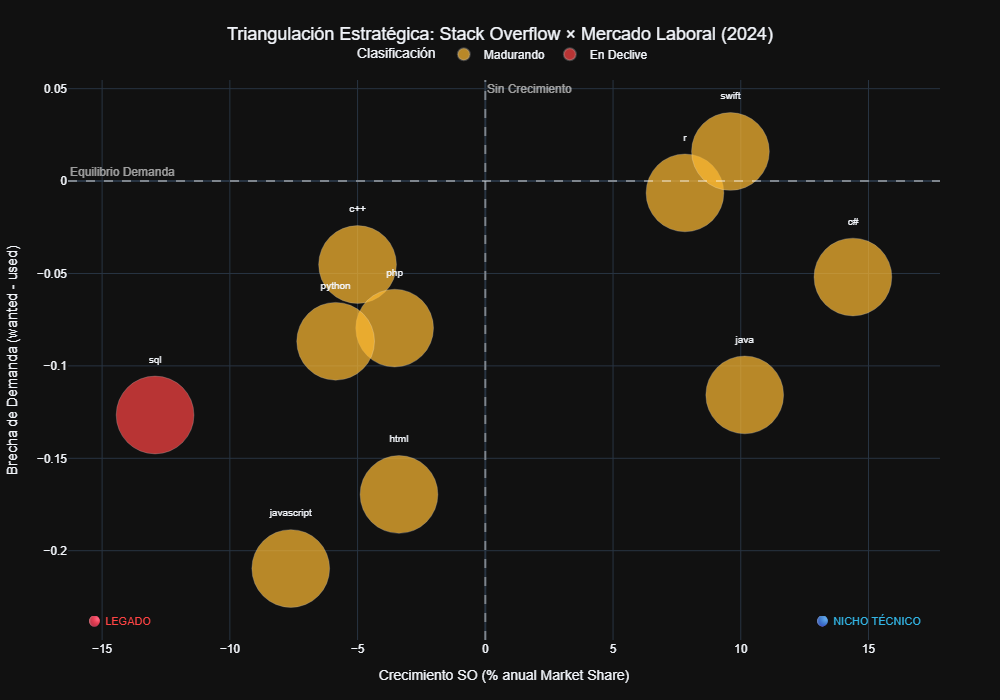

In [9]:
# 4.1 Preparar datos para Plotly (conversión mínima a pandas para px.scatter)
df_plot = df_cruce.select([
    'Tag', 'Pendiente', 'Crecimiento_Pct', 'Demand_Gap',
    'n_respondents', 'ViewCount_Promedio', 'Categoria_Tendencia'
]).to_pandas()

# 4.2 Mapa de colores estratégico
color_map = {
    'En Auge':    '#00C851',   # Verde vibrante
    'Madurando':  '#FFBB33',   # Ámbar
    'En Declive': '#FF4444',   # Rojo
}

# 4.3 Bubble Chart principal
fig = px.scatter(
    df_plot,
    x='Crecimiento_Pct',
    y='Demand_Gap',
    size='n_respondents',
    color='Categoria_Tendencia',
    color_discrete_map=color_map,
    text='Tag',
    hover_data={
        'Pendiente': ':.2f',
        'ViewCount_Promedio': ':.0f',
        'Crecimiento_Pct': ':.2f',
        'Demand_Gap': ':.4f',
        'n_respondents': ':,',
    },
    labels={
        'Crecimiento_Pct': 'Crecimiento SO (% anual Market Share)',
        'Demand_Gap': 'Brecha de Demanda (wanted - used)',
        'Categoria_Tendencia': 'Clasificación',
        'n_respondents': 'Encuestados',
    },
    title='Triangulación Estratégica: Stack Overflow × Mercado Laboral (2024)',
    size_max=55,
)

# 4.4 Líneas de referencia para crear los 4 cuadrantes
fig.add_hline(
    y=0, line_dash='dash', line_color='rgba(255,255,255,0.4)',
    annotation_text='Equilibrio Demanda',
    annotation_position='top left',
    annotation_font_color='rgba(255,255,255,0.6)'
)
fig.add_vline(
    x=0, line_dash='dash', line_color='rgba(255,255,255,0.4)',
    annotation_text='Sin Crecimiento',
    annotation_position='top right',
    annotation_font_color='rgba(255,255,255,0.6)'
)

# 4.5 Layout ejecutivo premium
fig.update_traces(
    textposition='top center',
    textfont_size=10,
    marker=dict(line=dict(width=1, color='rgba(255,255,255,0.3)')),
)

fig.update_layout(
    template='plotly_dark',
    height=700,
    width=1000,
    font=dict(family='Inter, sans-serif'),
    title_font_size=18,
    title_x=0.5,
    margin=dict(l=60, r=60, t=80, b=60),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='center',
        x=0.5,
        itemsizing='constant'
    ),
    # Anotaciones de cuadrantes
    annotations=[
        dict(x=0.98, y=0.98, xref='paper', yref='paper',
             text='🟢 ESTRELLA EMERGENTE', showarrow=False,
             font=dict(size=11, color='#00C851'), xanchor='right'),
        dict(x=0.02, y=0.98, xref='paper', yref='paper',
             text='🟡 OPORTUNIDAD OCULTA', showarrow=False,
             font=dict(size=11, color='#FFBB33'), xanchor='left'),
        dict(x=0.98, y=0.02, xref='paper', yref='paper',
             text='🔵 NICHO TÉCNICO', showarrow=False,
             font=dict(size=11, color='#33B5E5'), xanchor='right'),
        dict(x=0.02, y=0.02, xref='paper', yref='paper',
             text='🔴 LEGADO', showarrow=False,
             font=dict(size=11, color='#FF4444'), xanchor='left'),
    ]
)

fig.show()

---
## 5. Exportación del Artefacto Final

Seleccionamos las columnas clave del cruce y persistimos el resultado como artefacto Parquet para las siguientes fases del pipeline (dashboards, API, informe).

In [ ]:
# 5.1 Seleccionar columnas clave para el artefacto
columnas_export = [
    'Tag',
    'used_pct',
    'wanted_pct',
    'Demand_Gap',
    'n_respondents',
    'Crecimiento_Pct',
    'Pendiente',
    'R2',
    'ViewCount_Promedio',
    'Categoria_Tendencia',
]

df_export = df_cruce.select(columnas_export).sort('Tag')

# 5.2 Exportar a Parquet
df_export.write_parquet(OUTPUT_PATH)

print(f'✅ Artefacto exportado exitosamente:')
print(f'   📁 {OUTPUT_PATH}')
print(f'   📐 Shape: {df_export.shape}')
print(f'   🏷️  Tecnologías: {sorted(df_export["Tag"].to_list())}')
print()
display(df_export)

---
## Conclusiones de la Triangulación

Este cuaderno cruzó dos fuentes de información independientes para validar la hipótesis de que **Stack Overflow es un indicador adelantado de la demanda tecnológica**.

**Hallazgos clave:**
1. La **Brecha de Demanda** permite identificar tecnologías con alta tracción laboral incluso si aún no dominan el volumen de preguntas en SO.
2. El **Gráfico de Cuadrantes** sintetiza en una sola visualización la posición estratégica de cada tecnología.
3. El artefacto `tabla_cruce_final.parquet` queda disponible como fuente de verdad unificada para el dashboard interactivo.

**Siguiente paso:** Integrar estos datos en la Fase 4 (Dashboard Streamlit + API FastAPI).